# 6-2 순서를 예측하는 생성 모델 만들기

본 노트북은 본문 6-2 절의 코드 예제([코드 6-5] ~ [코드 6-10])를 절 흐름 그대로 모은 것이다. 단순 RNN(`nn.RNN`)으로 '반짝반짝 작은별' 멜로디를 학습하고, 자기회귀 방식으로 새 멜로디를 생성한다.

다루는 내용
- `[코드 6-5]` 멜로디를 학습하는 단순 RNN 모델 클래스
- `[코드 6-6]` 모델 객체 생성과 구조 확인
- `[코드 6-7]` '반짝반짝 작은별' 음계 데이터셋과 데이터로더
- `[코드 6-8]` 단순 RNN 모델의 학습
- `[코드 6-9]` 네 음계로 다음 한 음계 예측하기
- `[코드 6-10]` 정해진 길이의 멜로디를 생성

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, torchinfo 는 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q torch torchinfo

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
# import random

# import numpy as np
# import torch
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import DataLoader, Dataset
# from torchinfo import summary

common.set_seed()
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

device = common.get_device()

CUDA를 사용합니다.


## [코드 6-5] 멜로디를 학습하는 단순 RNN 모델 클래스

`MelodyRNN` 은 단순 RNN 계층(`self.rnn`)과 완전 연결 계층(`self.fc`)으로 구성된다. `batch_first=True` 로 `(B, S, input_size)` 형태의 입력을 받고, `forward()` 는 `outputs[:, -1, :]` 슬라이싱으로 마지막 시점의 숨겨진 상태만 골라 완전 연결 계층에 전달한다.

In [4]:
###############################################################################
# 코드 6-5 - 멜로디를 학습하는 단순 RNN 모델 클래스
###############################################################################

import torch.nn as nn

# 단순 RNN 계층을 사용하는 순환 신경망 모델 클래스
class MelodyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # 단순 RNN 계층 블록
        self.rnn = nn.RNN(
            input_size=input_size,      # 어휘 사전의 크기(각 토큰별 벡터의 크기)
            hidden_size=hidden_size,    # 숨겨진 상태의 크기
            batch_first=True,           # (B, S, input_size) 형태의 입력 사용
        )
        # 완전 연결 계층
        #     입력 크기: 숨겨진 상태 텐서의 크기
        #     출력 크기: 어휘 사전 크기(각 토큰별 원-핫 텐서 크기)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):                   # x: (B, S, input_size) 
        outputs, _ = self.rnn(x)            #    -> (B, S, hidden_size)
        # [:, -1, :] 슬라이싱으로 마지막 시점의 숨겨진 상태만 선택
        last_hidden = outputs[:, -1, :]     #    -> (B, hidden_size)
        # 완전 연결 계층을 통과해 최종 결과 산출
        return self.fc(last_hidden)         #    -> (B, output_size)

## [코드 6-6] 모델 객체 생성과 구조 확인

`input_size` 와 `output_size` 를 어휘 사전 크기인 8로, `hidden_size` 를 32로 설정해 모델 객체를 만든다. `torchinfo.summary()` 로 배치 크기 8, 입력 길이 4를 가정한 입력 텐서 `(8, 4, 8)` 에 대한 구조를 확인한다.

In [5]:
###############################################################################
# 코드 6-6 - 모델 객체 생성과 구조 확인
###############################################################################

import torch
from torchinfo import summary

model = MelodyRNN(8, 32, 8)
# 배치 크기(B)가 8, 입력 샘플 순차 데이터의 길이(S)가 4인 경우
# 입력 텐서의 형태 - (B, S, input_size) = (8, 4, 8)
summary(model, input_size=(8, 4, 8), device=torch.device('cpu'))

Layer (type:depth-idx)                   Output Shape              Param #
MelodyRNN                                [8, 8]                    --
├─RNN: 1-1                               [8, 4, 32]                1,344
├─Linear: 1-2                            [8, 8]                    264
Total params: 1,608
Trainable params: 1,608
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.02

파라미터 수는 단순 RNN 계층 1,344개, 완전 연결 계층 264개로 총 1,608개다.

## [코드 6-7] '반짝반짝 작은별' 음계 데이터셋과 데이터로더

여섯 음계와 쉼표(`_`), `<eos>` 까지 8개 토큰으로 어휘 사전을 만든 뒤, 크기 5인 윈도우로 입력 4음계·정답 1음계 쌍을 반환하는 `MelodyDataset` 을 정의한다. 입력은 원-핫 인코딩 실수형 텐서, 정답은 교차 엔트로피 손실용 `long` 자료형 고유 번호다.

In [6]:
###############################################################################
# 코드 6-7 - <반짝반짝 작은별> 음계 데이터셋과 데이터로더
###############################################################################

# <반짝반짝 작은별>: 도레미파솔라 여섯 음계와 쉼표(_)의 7개의 토큰으로 구성

from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
sequence = '도도솔솔라라솔_파파미미레레도_솔솔파파미미레_' \
           '솔솔파파미미레_도도솔솔라라솔_파파미미레레도_'

# 일반적으로 특수 토큰은 앞부분 고유 번호를 부여
EOS_TOKEN = '<eos>'                     # <eos> (순차 데이터의 끝) 특수 토큰
vocab = {EOS_TOKEN: 0}                  # 고유 번호 0번
# 데이터에 등장하는 토큰만으로 어휘 사전을 구성(시 제외)
# 중복 제거: 리스트를 집합(set)으로 변환해 제거
#     집합은 순서가 없는 자료형이므로 sorted()로 고정
for i, token in enumerate(sorted(set(sequence))):
    vocab[token] = i + 1
vocab_size = len(vocab)                 # 어휘 사전의 크기

# 데이터셋 클래스 정의
class MelodyDataset(Dataset):
    def __init__(self, sequence, vocab, window_size):
        self.vocab = vocab
        self.window_size = window_size
        # 순차 데이터에 <eos> 추가 후, 고유 번호 텐서로 변환
        token_list = list(sequence) + [EOS_TOKEN]
        self.sequence_idx = torch.tensor(
            [vocab[token] for token in token_list]
        )

    def __len__(self):
        # 슬라이딩 윈도우로 만들 수 있는 샘플 수 = 시퀀스 길이 - 윈도우 크기 + 1
        return len(self.sequence_idx) - self.window_size + 1

    def __getitem__(self, idx):
        subsequence = self.sequence_idx[idx: idx + self.window_size]
        # 입력: 앞 (window_size - 1)개 토큰을 원-핫 인코딩한 실수형 텐서
        x = F.one_hot(subsequence[:-1], num_classes=len(self.vocab)).float()
        # 정답: 마지막 토큰의 고유 번호
        #     nn.CrossEntropyLoss의 정답은 보통 torch.long 자료형을 사용
        label = subsequence[-1].long()
        return x, label


# 데이터셋과 데이터로더 생성
window_size = 5                         # 입력 길이 4, 정답 길이 1
little_star_dataset = MelodyDataset(sequence, vocab, window_size)
BATCH_SIZE = 8                          # 배치 크기
little_star_dataloader = DataLoader(
    little_star_dataset, batch_size=BATCH_SIZE, shuffle=True,
)

print('생성된 어휘 사전:', vocab)
print(f'어휘 사전의 크기: {vocab_size}')
print(f'데이터셋 샘플 수: {len(little_star_dataset)}개')
print('마지막 샘플:')               # 마지막 샘플의 정답 - <eos> (tensor(0))
print(little_star_dataset[len(little_star_dataset) - 1])

생성된 어휘 사전: {'<eos>': 0, '_': 1, '도': 2, '라': 3, '레': 4, '미': 5, '솔': 6, '파': 7}
어휘 사전의 크기: 8
데이터셋 샘플 수: 45개
마지막 샘플:
(tensor([[0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.]]), tensor(0))


어휘 사전 크기는 8, 샘플 수는 45개다. 마지막 샘플의 정답은 `<eos>`(tensor(0))로 멜로디의 끝을 나타낸다.

> `little_star_dataset[-1]` 처럼 음수 인덱스로 접근하면 `__getitem__()` 만 정의한 사용자 정의 클래스는 음수 인덱스를 그대로 받아 의도하지 않은 슬라이싱이 일어나 `IndexError` 가 발생한다. 그래서 마지막 샘플은 `len(...) - 1` 로 접근한다. 데이터로더는 0부터 `__len__()` 값까지의 양수 인덱스로만 접근하므로 학습에는 영향이 없다.

## 참고 - 학습 함수 정의 (`train_epoch` / `train_loop` 분해)

본문 [코드 6-8] 은 한 셀에 인라인 학습 루프를 담고 있다. 노트북에서는 공통 컨벤션(§7)에 따라 1 에포크 학습을 담당하는 `train_epoch()` 와 에포크 반복을 감싸는 `train_loop()` 로 분리해 재사용한다. 생성 모델이라 정확도가 의미 없으므로 검증 함수는 두지 않고 평균 훈련 손실만 반환한다.

In [7]:
# 참고: 학습 함수 정의 (train_epoch / train_loop 분해)

# 1 에포크 학습: 가중 평균 훈련 손실을 반환
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 학습 함수
def train(model, data_loader, criterion, optimizer, num_epochs, device=None):
    if device is None:
        device = torch.device('cpu')  # 기본값으로 CPU를 사용하도록 설정

    model.to(device)

    log = common.EpochLogger(num_epochs, columns=('훈련 손실',), formats=('{:.4f}',))
    for epoch in range(1, num_epochs + 1):
        train_loss = train_epoch(model, data_loader, criterion, optimizer, device)
        log.row(epoch, train_loss)
    log.plot(title='MelodyRNN의 학습 곡선')

## [코드 6-8] 단순 RNN 모델의 학습

교차 엔트로피 손실과 Adam 옵티마이저로 200 에포크 동안 모델을 학습한다. 다음 음계를 예측하는 것은 결국 모든 음계의 로짓 중 가장 점수가 높은 하나를 고르는 분류 작업과 본질이 같으므로, 생성을 위한 예측에도 분류 모델의 메커니즘을 그대로 쓴다.

  epoch    훈련 손실     시간
  1/200       2.0611     0:00
 20/200       1.2443     0:01
 40/200       0.7401     0:01
 60/200       0.5414     0:01
 80/200       0.4141     0:01
100/200       0.3312     0:02
120/200       0.2766     0:02
140/200       0.2421     0:02
160/200       0.2177     0:02
180/200       0.2010     0:02
200/200       0.1889     0:03


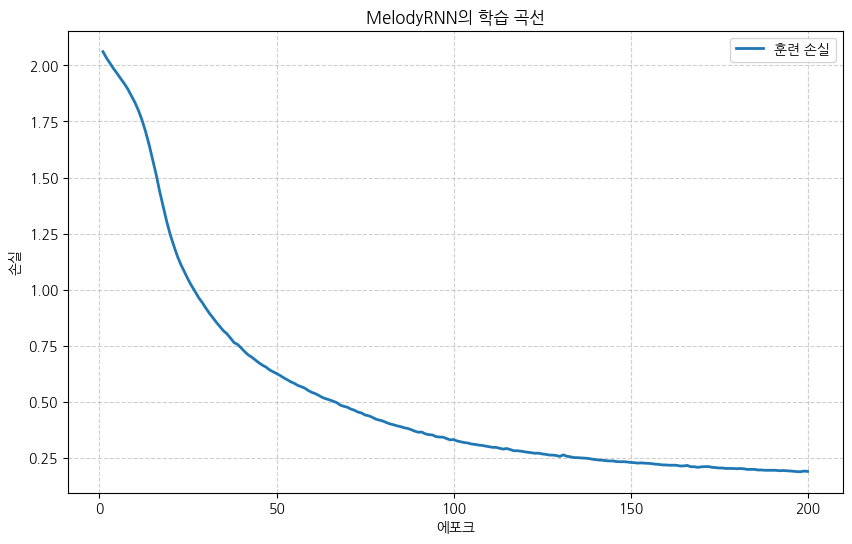

In [8]:
###############################################################################
# 코드 6-8 - 단순 RNN 모델의 학습
###############################################################################

import torch.optim as optim

# 하이퍼파라미터
LR = 0.001                             # 학습률
EPOCHS = 200                           # 전체 학습 에포크

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 학습 루프: 조기 종료 방식 미적용, device는 미리 구해 둔 장치 객체
train(model, little_star_dataloader, criterion, optimizer, EPOCHS, device)

훈련 손실이 200 에포크에 걸쳐 꾸준히 감소한다. 다만 이것만으로 생성 모델이 잘 학습되었는지는 알 수 없으므로, 직접 생성 결과를 확인해야 한다.

## [코드 6-9] 네 음계로 다음 한 음계 예측하기

학습된 모델로 네 음계를 입력해 다음 한 음계를 예측한다. 입력 4개 토큰을 원-핫 인코딩하면 `(4, 8)` 이 되고, 배치 차원을 추가해 `(1, 4, 8)` 텐서를 모델에 전달한다. 출력 로짓에서 `argmax()` 로 가장 점수가 높은 인덱스를 구한 뒤, 역방향 어휘 사전으로 토큰을 되돌린다.

In [9]:
###############################################################################
# 코드 6-9 - 네 음계로 다음 한 음계 예측하기
###############################################################################

# 마중물(이전 4개의 음)로 다음 음을 예측하는 예측 함수
def predict_next(model, sequence, vocab, reversed_vocab, device=None):
    if device is None:
        device = torch.device('cpu')
    # 단순 RNN 모델은 길이 4의 순차 데이터를 입력받음
    if len(sequence) < 4:
        raise ValueError('예측에는 최소 4개의 음이 필요합니다.')
    # 네 음 이상 입력해도 마지막 네 음으로 예측
    sequence = sequence[-4:] 

    model.eval()
    # 원-핫 인코딩된 (4, 8) 텐서에 배치 차원 추가 -> (1, 4, 8)
    sequence_idx = torch.tensor([vocab[token] for token in sequence])
    input_tensor = F.one_hot(sequence_idx, len(vocab)).float().unsqueeze(0)
    # 예측용 마중물 텐서는 모델과 같은 장치에 위치해야 함
    input_tensor = input_tensor.to(device)
    # 모델 예측 결과(음별 로짓)를 바탕으로 다음 음 예측
    with torch.no_grad():
        prediction = model(input_tensor)
        predicted_idx = torch.argmax(prediction).item()
    # 역방향 어휘 사전으로 토큰을 구해 반환
    return reversed_vocab[predicted_idx]

input_sequence = '도도솔솔'             # 예측을 위한 마중물 음
# 역방향 어휘 사전: 어휘 사전의 방향을 바꾼 딕셔너리(고유번호 -> 음)
reversed_vocab = {i: token for token, i in vocab.items()}
next_token = predict_next(model, input_sequence, vocab, reversed_vocab, device)
print(f'다음 음: {next_token}')         

다음 음: 라


## [코드 6-10] 정해진 길이의 멜로디를 생성

가장 최근 네 음계로 다음 음계를 예측하고, 그 결과를 다시 입력에 붙여 이어서 예측하는 과정을 반복해 멜로디를 생성한다. `<eos>` 토큰이 예측되면 생성을 조기 종료한다.

In [12]:
###############################################################################
# 코드 6-10 - 정해진 길이의 멜로디를 생성
###############################################################################

# 생성 함수
#     마중물(start_sequence)로 시작해서 정해진 길이(generated_length)만큼 생성
#     종료 토큰(eos_token)을 예측하면 정해진 길이 이전에 생성 종료
def generate_sequence(model, start_sequence, generated_length, 
                      vocab, eos_token, device):
    if device is None:
        device = torch.device('cpu')
    reversed_vocab = {i: token for token, i in vocab.items()}
    result = list(start_sequence)
    for _ in range(generated_length):
        next_token = predict_next(model, result[-4:], vocab, 
                                  reversed_vocab, device)
        result.append(next_token)
        # 생성 도중 <eos>가 나오면 길이와 상관없이 종료
        if eos_token is not None and next_token == eos_token:
            break
    return result

# '반짝반짝 작은별'에 포함된 멜로디로 시작
generated = generate_sequence(model, '도도솔솔', 32, vocab, EOS_TOKEN, device)
print(f"'도도솔솔'로 생성: {''.join(generated)}")

# '반짝반짝 작은별'에 포함되지 않은 멜로디로 시작
generated = generate_sequence(model, '도레미파', 32, vocab, EOS_TOKEN, device)
print(f"'도레미파'로 생성: {''.join(generated)}")

'도도솔솔'로 생성: 도도솔솔라라솔_파파미미레레도_솔솔파파미미레레도_솔솔파파미미레레도_
'도레미파'로 생성: 도레미파파레_레레파파미미레레도_솔솔파파미미레레도_솔솔파파미미레레도


## 정리

- 다음 토큰 예측 모델을 자기회귀 방식으로 반복 호출하면 새로운 순차 데이터를 생성할 수 있다.
- 생성 모델은 단일 정답이 없으므로 손실·정확도만으로 성능을 가늠하기 어렵고, 생성 결과를 직접 확인하는 정성 평가가 함께 필요하다.
- 학습 데이터가 적으면 같은 입력에 다른 패턴이 섞여 모델이 혼란을 겪고, `<eos>` 가 정답인 샘플이 드물어 종료 시점을 제대로 학습하지 못한다.